# Chapter 2 — Vectors and Vector Geometry: Code Companion

This notebook makes the ideas in `notes.md` concrete. Run cell by cell.

We'll use:
- `numpy` for vectors and dot products
- `matplotlib` for pictures in ℝ²

Run from the project root: `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. Points vs vectors — and the displacement

Two points `A` and `B` in ℝ². Their displacement `**AB** = B − A` is a vector.

In [2]:
A = np.array([1.0, 2.0])
B = np.array([5.0, 5.0])

AB = B - A
print('A          =', A)
print('B          =', B)
print('AB = B-A   =', AB)
print('|AB|       =', np.linalg.norm(AB))

A          = [1. 2.]
B          = [5. 5.]
AB = B-A   = [4. 3.]
|AB|       = 5.0


## 2. Dot product — algebra and geometry agree

Compute `u · v` two ways:
1. Algebraically: `∑ uᵢ vᵢ`
2. Geometrically: `‖u‖ · ‖v‖ · cos θ`

They must agree.

In [3]:
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])

dot_alg = u @ v                      # NumPy's @ is the dot product for 1-D arrays
norm_u  = np.linalg.norm(u)
norm_v  = np.linalg.norm(v)
cos_t   = dot_alg / (norm_u * norm_v)
theta   = np.arccos(cos_t)

print(f'u · v (algebraic)    = {dot_alg:.4f}')
print(f'|u| · |v| · cos θ    = {norm_u * norm_v * cos_t:.4f}')
print(f'cos θ                = {cos_t:.4f}')
print(f'θ in degrees         = {np.degrees(theta):.2f}°')

u · v (algebraic)    = 24.0000
|u| · |v| · cos θ    = 24.0000
cos θ                = 0.9600
θ in degrees         = 16.26°


## 3. Visualize the angle between two vectors

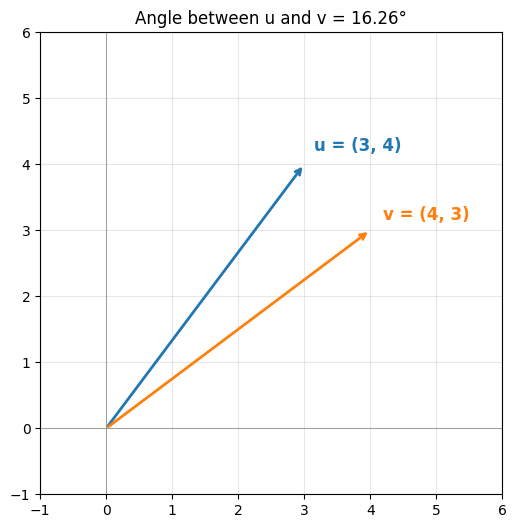

In [4]:
def draw_arrow(ax, vec, color, label, start=(0, 0), lw=2):
    ax.annotate('', xy=(start[0] + vec[0], start[1] + vec[1]),
                xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    ax.text(start[0] + vec[0]*1.05, start[1] + vec[1]*1.05, label,
            color=color, fontsize=12, fontweight='bold')

fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)

draw_arrow(ax, u, 'tab:blue',   'u = (3, 4)')
draw_arrow(ax, v, 'tab:orange', 'v = (4, 3)')

ax.set_xlim(-1, 6); ax.set_ylim(-1, 6); ax.set_aspect('equal')
ax.set_title(f'Angle between u and v = {np.degrees(theta):.2f}°')
plt.show()

## 4. The sign of u · v tells you acute / right / obtuse

Three pairs of vectors — one acute, one right, one obtuse.

In [5]:
pairs = {
    'acute':   (np.array([2.0, 1.0]), np.array([1.0, 2.0])),
    'right':   (np.array([3.0, 4.0]), np.array([4.0, -3.0])),
    'obtuse':  (np.array([2.0, 1.0]), np.array([-1.0, 2.0])),
}

for name, (a, b) in pairs.items():
    d = a @ b
    angle_deg = np.degrees(np.arccos(d / (np.linalg.norm(a) * np.linalg.norm(b))))
    print(f'{name:8s}  u={a}  v={b}   u·v={d:+.2f}   θ={angle_deg:.2f}°')

acute     u=[2. 1.]  v=[1. 2.]   u·v=+4.00   θ=36.87°
right     u=[3. 4.]  v=[ 4. -3.]   u·v=+0.00   θ=90.00°
obtuse    u=[2. 1.]  v=[-1.  2.]   u·v=+0.00   θ=90.00°


## 5. Projection of u onto v, with the picture

Decompose `u = proj_v u + (u − proj_v u)` into the part along `v` and the part perpendicular to `v`.

In [6]:
def project(u, v):
    """Project u onto the line through v."""
    return (u @ v) / (v @ v) * v

u = np.array([5.0, 1.0])
v = np.array([3.0, 4.0])

p     = project(u, v)
perp  = u - p

print('u           =', u)
print('v           =', v)
print('proj_v u    =', p)
print('u - proj    =', perp)
print('perp · v    =', perp @ v, '  (should be ~0)')
print('Pythagoras:  |proj|^2 + |perp|^2 =', np.linalg.norm(p)**2 + np.linalg.norm(perp)**2)
print('              |u|^2              =', np.linalg.norm(u)**2)

u           = [5. 1.]
v           = [3. 4.]
proj_v u    = [2.28 3.04]
u - proj    = [ 2.72 -2.04]
perp · v    = 0.0   (should be ~0)
Pythagoras:  |proj|^2 + |perp|^2 = 26.0
              |u|^2              = 25.999999999999996


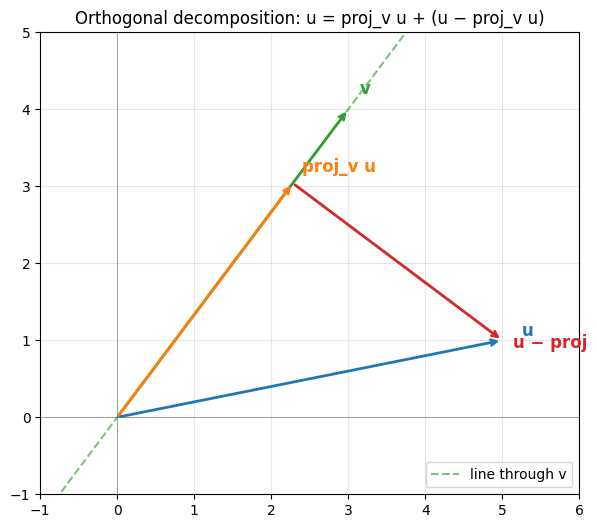

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)

# extend v as a faint line to show the projection axis
ts = np.linspace(-0.3, 1.6, 50)
line = np.outer(ts, v)
ax.plot(line[:, 0], line[:, 1], 'g--', alpha=0.5, label='line through v')

draw_arrow(ax, u,    'tab:blue',   'u')
draw_arrow(ax, v,    'tab:green',  'v')
draw_arrow(ax, p,    'tab:orange', 'proj_v u')
# the perpendicular drop, drawn from tip of proj to tip of u
draw_arrow(ax, perp, 'tab:red',    'u − proj', start=p)

ax.set_xlim(-1, 6); ax.set_ylim(-1, 5); ax.set_aspect('equal')
ax.legend(loc='lower right')
ax.set_title('Orthogonal decomposition: u = proj_v u + (u − proj_v u)')
plt.show()

## 6. Parametric line through two points

A line through `A` in direction `v = B − A` is `L(t) = A + t·v`.

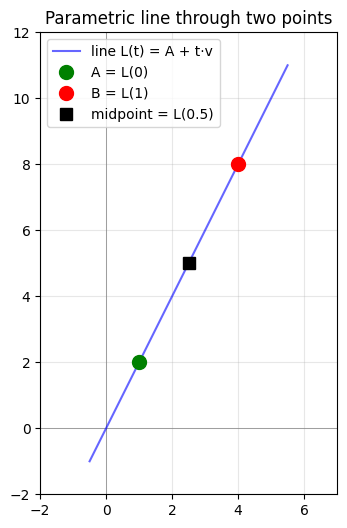

In [8]:
A = np.array([1.0, 2.0])
B = np.array([4.0, 8.0])
v = B - A

ts = np.linspace(-0.5, 1.5, 60)
pts = A[None, :] + ts[:, None] * v[None, :]

fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)

ax.plot(pts[:, 0], pts[:, 1], 'b-', alpha=0.6, label='line L(t) = A + t·v')
ax.plot(*A, 'go', markersize=10, label='A = L(0)')
ax.plot(*B, 'ro', markersize=10, label='B = L(1)')
ax.plot(*((A + B) / 2), 'ks', markersize=8, label='midpoint = L(0.5)')

ax.set_xlim(-2, 7); ax.set_ylim(-2, 12); ax.set_aspect('equal')
ax.legend()
ax.set_title('Parametric line through two points')
plt.show()

## 7. Cosine similarity and high-dimensional orthogonality

Two random vectors in ℝⁿ for big n are *almost always* nearly orthogonal. This is the geometric reason embedding-based search works.

Sample 1000 random pairs in ℝ³, ℝ¹⁰, ℝ¹⁰⁰, ℝ¹⁰⁰⁰ and look at the distribution of cosine similarities.

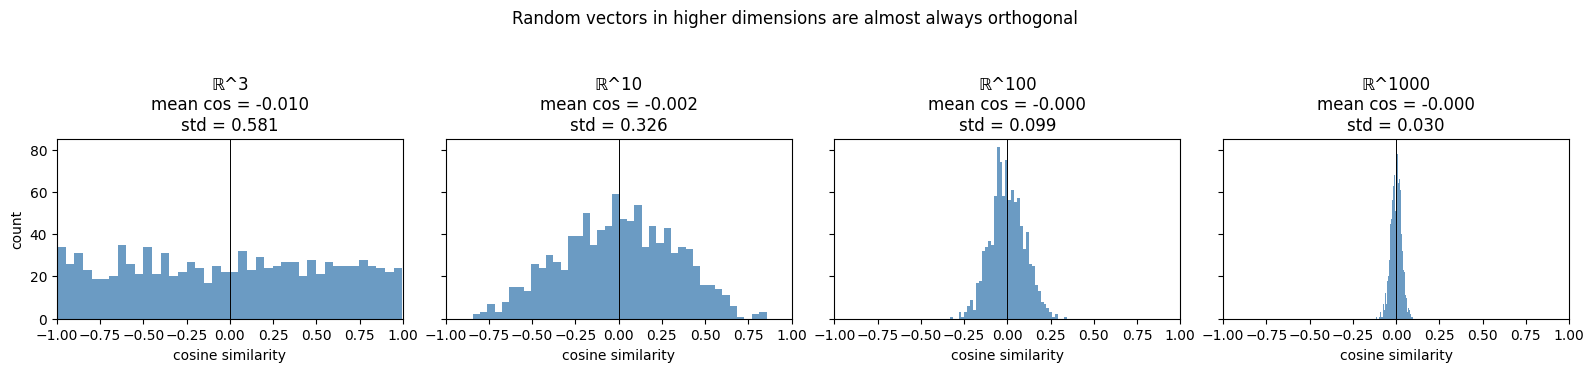

In [9]:
def cos_sim(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

rng = np.random.default_rng(0)
dims = [3, 10, 100, 1000]
n_trials = 1000

fig, axes = plt.subplots(1, len(dims), figsize=(16, 3.5), sharey=True)
for ax, d in zip(axes, dims):
    sims = [cos_sim(rng.normal(size=d), rng.normal(size=d)) for _ in range(n_trials)]
    ax.hist(sims, bins=40, color='steelblue', alpha=0.8)
    ax.axvline(0, color='k', lw=0.7)
    ax.set_xlim(-1, 1)
    ax.set_title(f'ℝ^{d}\nmean cos = {np.mean(sims):+.3f}\nstd = {np.std(sims):.3f}')
    ax.set_xlabel('cosine similarity')
axes[0].set_ylabel('count')
fig.suptitle('Random vectors in higher dimensions are almost always orthogonal', y=1.05)
plt.tight_layout()
plt.show()

Notice how the histogram tightens around zero as the dimension grows. In ℝ¹⁰⁰⁰, two random vectors have cosine similarity ≈ 0 with very high probability — they are nearly perpendicular. This is what makes embeddings useful: the few vectors that are *not* nearly orthogonal stand out as semantic neighbours.

## 8. Cauchy–Schwarz, empirically

For random `u, v ∈ ℝⁿ`, the inequality `|u · v| ≤ ‖u‖ · ‖v‖` should *always* hold.

In [10]:
rng = np.random.default_rng(1)
violations = 0
for _ in range(10_000):
    u = rng.normal(size=50)
    v = rng.normal(size=50)
    if abs(u @ v) > np.linalg.norm(u) * np.linalg.norm(v) + 1e-9:
        violations += 1

print(f'Cauchy–Schwarz violations across 10,000 random pairs in ℝ⁵⁰: {violations}')
print('(Should be 0.)')

Cauchy–Schwarz violations across 10,000 random pairs in ℝ⁵⁰: 0
(Should be 0.)


## 9. Mini-project — distance from a point to a line

Use the projection formula to find the perpendicular distance from a point to a line through origin.

In [11]:
def distance_point_to_line_through_origin(P, v):
    """Perpendicular distance from point P to the line through 0 in direction v."""
    proj = (P @ v) / (v @ v) * v
    return np.linalg.norm(P - proj)

P = np.array([7.0, 0.0])
v = np.array([2.0, 1.0])
print(f'distance = {distance_point_to_line_through_origin(P, v):.4f}')
print(f'(exercise 9 expected ≈ 7/√5 = {7/np.sqrt(5):.4f})')

distance = 3.1305
(exercise 9 expected ≈ 7/√5 = 3.1305)


---

## What's next

Chapter 3 starts solving linear systems `Ax = b` systematically. The parametric line `L(t) = A + tv` you saw in section 6 will reappear as the *general solution* of an underdetermined system. The dot product will reappear as the building block of *every* matrix-vector product. Worth coming back to this notebook later to see those connections.

Read `notes.md`, work `worked-examples.md`, do `exercises.md`, then re-run this notebook with your own examples.